## Importation des bibiotheques

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

### Exercice_01

Objectif : Comprendre la structure, la qualité et la cohérence du jeu de données.
1.	Indiquer :
-	le nombre de lignes
-	le nombre de colonnes
-	les types de données de chaque variable
2.	Identifier :
-	les valeurs manquantes
-	les éventuels doublons
3.	Calculer les statistiques descriptives pour :
-	l’âge
-	la durée de la fièvre
4.	Explorer la distribution de la température corporelle et identifier les valeurs aberrantes
5.	Compter les valeurs uniques pour :
-	le sexe
-	le résultat du test typhoïde
-	la source d’eau


In [3]:
# charger le fichier
df = pd.read_csv('typhoide_health_data.csv')

# obtenir les dimensions
lignes, colonnes = df.shape

print(f"Nombre de lignes : {lignes}")
print(f"Nombre de colonnes : {colonnes}")

Nombre de lignes : 300
Nombre de colonnes : 9


In [4]:
# le type de donnee de chaque variable

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   300 non-null    int64  
 1   Sexe                  300 non-null    object 
 2   Region                300 non-null    object 
 3   Temperature           300 non-null    float64
 4   Duree_fievre          300 non-null    int64  
 5   Test_typhoide         300 non-null    object 
 6   Source_eau            300 non-null    object 
 7   Acces_assainissement  300 non-null    object 
 8   Antibiotherapie       300 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 21.2+ KB


In [5]:
# les valeurs manquantes 
df.isnull().sum()

Age                     0
Sexe                    0
Region                  0
Temperature             0
Duree_fievre            0
Test_typhoide           0
Source_eau              0
Acces_assainissement    0
Antibiotherapie         0
dtype: int64

In [6]:
# si on veut le pourcentage des valeur manquante
df.isnull().mean()*100

Age                     0.0
Sexe                    0.0
Region                  0.0
Temperature             0.0
Duree_fievre            0.0
Test_typhoide           0.0
Source_eau              0.0
Acces_assainissement    0.0
Antibiotherapie         0.0
dtype: float64

#### commentaire des resultats:
on n'a pas de valeurs manquante dans le jeu de donnee

In [7]:
# compter les valeurs doubles
df.duplicated().sum()

np.int64(0)

In [10]:
# description statistique des variables age 
print("================Age==================")
print(df['Age'].describe())
print("===============Duree_fievre==============")
print(df['Duree_fievre'].describe())

================Age==================
count    300.000000
mean      39.993333
std       22.276462
min        1.000000
25%       20.000000
50%       39.500000
75%       58.250000
max       80.000000
Name: Age, dtype: float64
===============Duree_fievre==============
count    300.000000
mean       7.360000
std        3.994612
min        1.000000
25%        4.000000
50%        7.000000
75%       11.000000
max       14.000000
Name: Duree_fievre, dtype: float64


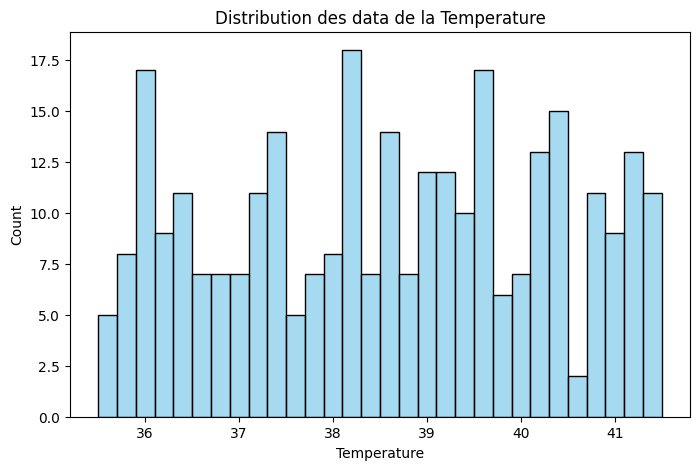

In [12]:
# histogramme (repartition par tranches)

plt.figure(figsize=(8, 5))
sns.histplot(df['Temperature'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution des data de la Temperature')
plt.show()

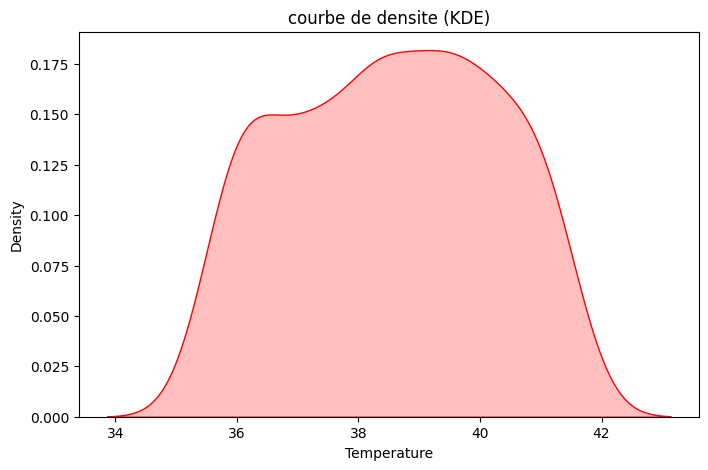

In [13]:
# diagramme de densite 
plt.figure(figsize=(8, 5))
sns.kdeplot(df['Temperature'], fill=True, color="red")
plt.title('courbe de densite (KDE)')
plt.show()

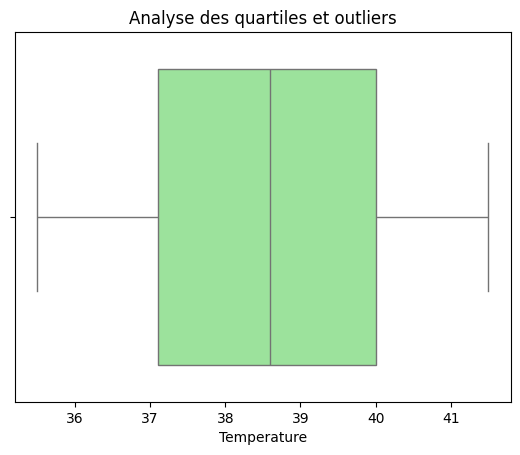

In [17]:
# boite a moustaches 
plt.Figure(figsize=(8, 5))
sns.boxplot(x=df['Temperature'], color='lightgreen')
plt.title('Analyse des quartiles et outliers')
plt.show()

Il y'a pas de valeur aberante

In [18]:
# les valeurs uniques
# sexe
n = df['Sexe'].nunique()
print(f"Il y'a {n} sexe unique ")
#
n = df['Test_typhoide'].nunique()
print(f"Il y'a {n} Test_typhoide unique ")
#
n = df['Source_eau'].nunique()
print(f"Il y'a {n} Source_eau unique ")

Il y'a 2 sexe unique 
Il y'a 2 Test_typhoide unique 
Il y'a 3 Source_eau unique 


### Exercice 2 : Analyse descriptive et épidémiologique
Objectif : Identifier les tendances associées à la fièvre typhoïde.
1.	Comparer la température moyenne entre les patients :
-	testés positifs
-	testés négatifs
2.	Calculer le taux de positivité à la typhoïde par région
3.	Évaluer si les personnes sans accès à l’assainissement sont plus souvent testées positives
4.	Comparer la durée moyenne de la fièvre entre les patients positifs et négatifs
5.	Analyser l’association entre la source d’eau et le résultat du test


In [27]:
# Compare la moyenne, la médiane et l'écart-type entre les deux groupes
comparaison = df.groupby('Test_typhoide')['Temperature'].agg(['mean', 'median', 'std', 'count'])
print(comparaison)

                    mean  median       std  count
Test_typhoide                                    
Negatif        37.936522    37.4  1.733131    115
Positif        38.921081    39.1  1.581805    185


<Axes: xlabel='Test_typhoide', ylabel='Temperature'>

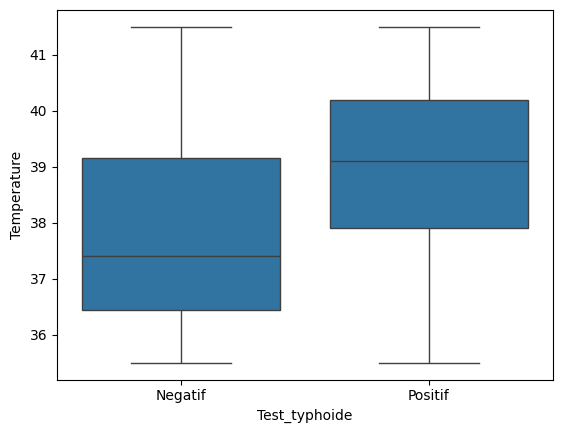

In [28]:
sns.boxplot(x='Test_typhoide', y='Temperature', data=df)

<Axes: xlabel='Temperature', ylabel='Density'>

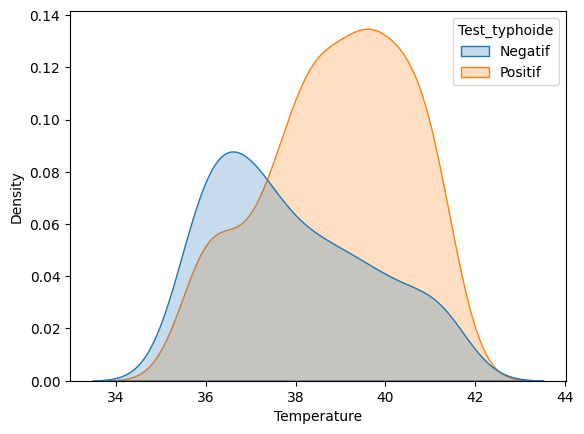

In [29]:
sns.kdeplot(data=df, x='Temperature', hue='Test_typhoide', fill=True)

Le taux de positivité s'exprime en pourcentage. Il représente la proportion de résultats positifs par rapport au nombre total de tests effectués.$$Taux\ de\ positivité = \left( \frac{\text{Nombre de cas positifs}}{\text{Nombre total de tests (positifs + négatifs)}} \right) \times 100$$

In [30]:
# calcul du taux de positivite 
counts = df['Test_typhoide'].value_counts()
print(counts)
print(counts['Positif'])
# calcule le taux
taux_de_productivite = (counts['Positif']/len(df))*100
print(f"le taux de positivite est de : {taux_de_productivite:.2f}%")

Test_typhoide
Positif    185
Negatif    115
Name: count, dtype: int64
185
le taux de positivite est de : 61.67%


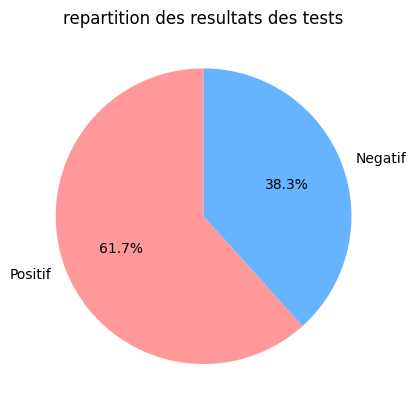

In [34]:
labels = ['Positif', 'Negatif']
sizes = [counts['Positif'], counts['Negatif']]
colors = ['#ff9999', '#66b3ff']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('repartition des resultats des tests')
plt.show()

In [36]:
pd.crosstab(df['Acces_assainissement'], df['Test_typhoide'])

Test_typhoide,Negatif,Positif
Acces_assainissement,,
Non,52,94
Oui,63,91


<Axes: xlabel='Acces_assainissement', ylabel='count'>

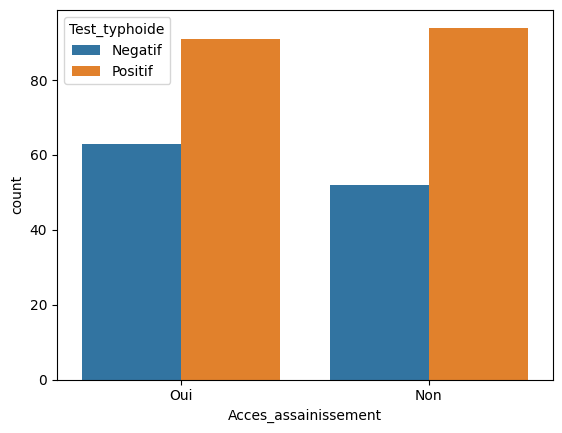

In [37]:
sns.countplot(x='Acces_assainissement', hue='Test_typhoide', data=df)

In [40]:
df.groupby('Test_typhoide')['Duree_fievre'].agg('mean','median', 'std', 'count')

Test_typhoide
Negatif    6.078261
Positif    8.156757
Name: Duree_fievre, dtype: float64

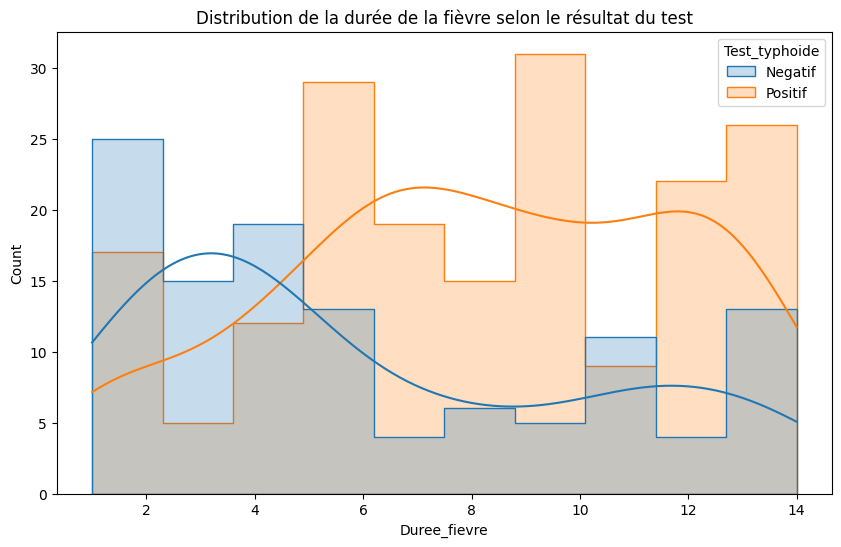

In [41]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Duree_fievre', hue='Test_typhoide', kde=True, element="step")
plt.title('Distribution de la durée de la fièvre selon le résultat du test')
plt.show()

In [46]:
#comptage 
contingence = pd.crosstab(df['Source_eau'], df['Test_typhoide'])
print(contingence)

Test_typhoide  Negatif  Positif
Source_eau                     
Potable             34       63
Puits               40       59
Riviere             41       63


In [43]:
proportions = pd.crosstab(df['Source_eau'], df['Test_typhoide'], normalize='index') * 100
print(proportions)

Test_typhoide    Negatif    Positif
Source_eau                         
Potable        35.051546  64.948454
Puits          40.404040  59.595960
Riviere        39.423077  60.576923


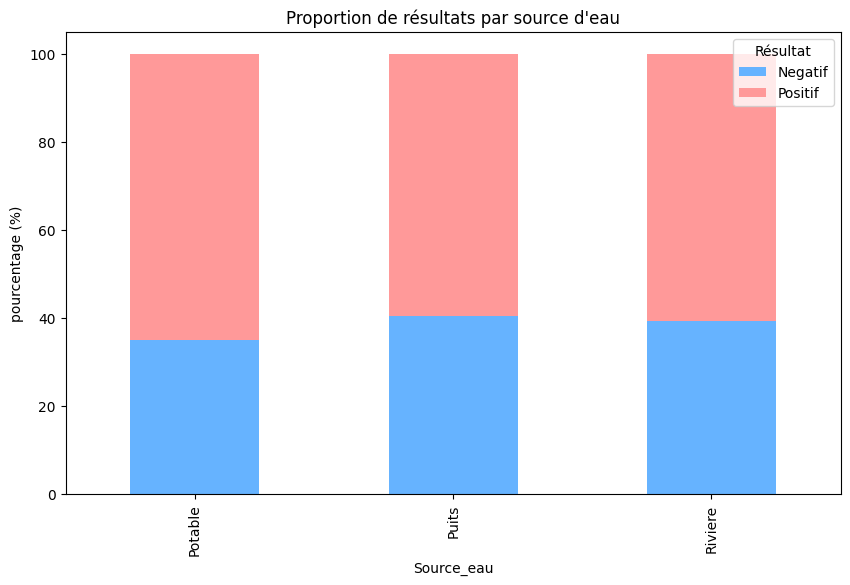

In [44]:
proportions.plot(kind='bar', stacked=True, color=['#66b3ff', '#ff9999'], figsize=(10,6))
plt.ylabel('pourcentage (%)')
plt.title('Proportion de résultats par source d\'eau')
plt.legend(title='Résultat', loc='upper right')
plt.show()

In [ ]:
# khi-deux
stat, p, dof, expected = chi2_contingency(contingence)
print(f"Statistique du Khi-deux : {stat:.2f}")
print(f"P-value : {p:.4f}")

Statistique du Khi-deux : 0.67
P-value : 0.7140


$P > 0.05$ : On ne peut pas conclure. Les différences observées sont peut-être dues au hasard

In [49]:
n =contingence.sum().sum() #nombre total d'individue
min_dim = min(contingence.shape) - 1

cramer_v = np.sqrt(stat/ (n*min_dim))
print(f"V de Cramér : {cramer_v:.3f}")

V de Cramér : 0.047


Interprétation du V de Cramér :

< 0.10 : Association très faible.

0.10 à 0.30 : Association moyenne (influence notable).

> 0.50 : Association très forte (la source d'eau est un prédicteur majeur du résultat)

### Exercice 3 : Analyse de la qualité des données
Objectif : Identifier et proposer des solutions aux problèmes de données.
1.	Identifier les valeurs de température physiologiquement impossibles
(ex. : 30°C, 45°C, 100°C) et expliquer pourquoi elles posent problème
2.	Compter les valeurs manquantes dans la variable Durée_fièvre et discuter :
-	suppression
-	imputation
-	conservation
3.	Vérifier les incohérences dans :
-	Sexe (M, m, Masculin…)
-	Test_typhoide (positif, Positif, POSITIF…)
4.	Proposer des règles de validation pour garantir la qualité future des données


In [51]:
# voyons combien de temperature son physiologiquement impossible
outliers_temp = df[(df['Temperature'] < 30) | (df['Temperature']>45)]
print(f"Nombre de températures impossibles : {len(outliers_temp)}")

Nombre de températures impossibles : 0


In [53]:
# valeurs manquante dans la variable duree fievre
manquantes = df[df['Duree_fievre'].isnull()]
print(f"Nombre de duree fievre est : {len(manquantes)}")

Nombre de duree fievre est : 0


on va conserver le dataset il est sans valeurs manquantes

In [54]:
print(df['Sexe'].unique())
print(df['Test_typhoide'].unique())

['M' 'F']
['Negatif' 'Positif']


#### Corriger les incohérences (Normalisation)
Il faut ramener chaque variable à un format unique et propre.

Pour la colonne Sexe
On veut transformer tout ce qui ressemble à un homme en "M" et tout ce qui ressemble à une femme en "F"

In [55]:
# Mettre tout en majuscules et enlever les espaces inutiles
df['Sexe'] = df['Sexe'].str.strip().str.upper()

# Remplacer les variantes par une valeur unique
mapping_sexe = {
    'MASCULIN': 'M',
    'HOMME': 'M',
    'FEMININ': 'F',
    'FEMME': 'F'
}
df['Sexe'] = df['Sexe'].replace(mapping_sexe)

#### Pour la colonne Test_typhoide
Ici, on veut simplement que "positif", "Positif" et "POSITIF" deviennent une seule et même catégorie.

In [56]:
# On met tout en minuscule pour uniformiser
df['Test_typhoide'] = df['Test_typhoide'].str.strip().str.lower()

# Résultat : il ne restera que 'positif' et 'negatif'

In [57]:
# Voir toutes les variantes de la colonne Sexe
print(df['Sexe'].value_counts())

# Voir toutes les variantes du test
print(df['Test_typhoide'].value_counts())

Sexe
F    156
M    144
Name: count, dtype: int64
Test_typhoide
positif    185
negatif    115
Name: count, dtype: int64


<Axes: xlabel='Sexe', ylabel='count'>

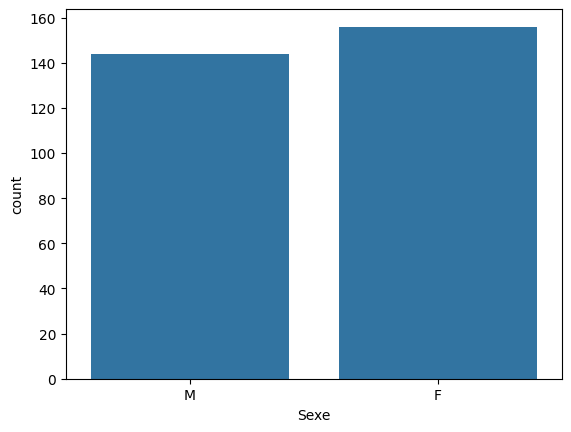

In [58]:
sns.countplot(x='Sexe', data=df)